In [1]:
from anomalib.data import MVTecAD
from anomalib.engine import Engine
from anomalib.models import Fastflow
from anomalib.models import Padim
from anomalib.models.image.fastflow import FastflowModel
from anomalib.data.datasets.base import AnomalibDataset
from anomalib.data.utils import LabelName
from anomalib.metrics.evaluator import Evaluator
from anomalib.metrics import AUROC, F1Score
from anomalib.loggers import AnomalibMLFlowLogger
from anomalib.data.dataclasses.torch import ImageItem, ImageBatch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ── Métricas — las mismas que ya usas ────────────────────────────────────────
from torchmetrics.classification import (
    BinaryAUROC,
    BinaryF1Score,
    BinaryPrecision,
    BinaryRecall,
    BinaryConfusionMatrix,
)

import mlflow
import mlflow.pytorch
import os

os.environ["MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING"] = "true"

# ── MLflow autolog — registra el modelo automáticamente al final de cada run ──
mlflow.pytorch.autolog(log_models=True, log_every_n_epoch=1, silent=True)

W0416 20:19:26.195000 22720 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [3]:
from dataset import CustomDataset

train_ds = CustomDataset(root="./datasets/robotV2",split="train")
test_ds  = CustomDataset(root="./datasets/robotV2", split="test")

train_dataloader, test_dataloader, val_dataloader = CustomDataset.get_dataloaders(train_ds,test_ds)

In [ ]:
train_ds[0]

In [ ]:

class CustomDataset(AnomalibDataset):
    """Custom dataset implementation."""

    def __init__(
        self,
        root: Path | str = "./datasets/robotV2",
        category: str = "default",
        transform = None,
        split = None,
    ):
        super().__init__()

        # Set up dataset
        self.root = Path(root)
        self.category = category
        self.split = split

        # Create samples DataFrame
        self.samples = self._make_dataset()

    def _make_dataset(self) -> pd.DataFrame:
        """Create dataset samples DataFrame."""
        samples_list = []

        
        if self.split == "train":
        
            # Collect normal samples
            normal_path = self.root / "train/good"
            images = normal_path.glob("*.png")
            for image_path in images:
                samples_list.append({
                    "image_path": str(image_path),
                    "gt_label": 0,
                    "label_index": LabelName.NORMAL,
                    "split": "train",
                    "gt_mask" : None,
                    "mask_path" : None
                })


        if self.split == "test":
            # Collect anomalous samples
            anomaly_path = self.root / "test/anomaly"
            anomaly_images = anomaly_path.glob("*.png")
            for image_path in anomaly_images:
                #mask_path = anomaly_path / "masks" / f"{image_path.stem}_mask.png"
                samples_list.append({
                    "image_path": str(image_path),
                    "split": "test",
                    "label_index": LabelName.ABNORMAL,
                    "gt_label" : 1,
                    "gt_mask" : None,
                    "mask_path" : None
                    
                })
                        # Collect normal samples
            normal_path = self.root / "test/good"
            images = normal_path.glob("*.png")
            for image_path in images:
                samples_list.append({
                    "image_path": str(image_path), 
                    "split": "test",
                    "label_index": LabelName.NORMAL,
                    "gt_label" : 0,
                    "gt_mask" : None,
                    "mask_path" : None
                })    
                


        # Create DataFrame
        samples = pd.DataFrame(samples_list)
        samples.attrs["task"] = "classification"
        return samples
        
   
        
train_ds = CustomDataset(root="./datasets/robotV2",split="train")
test_ds  = CustomDataset(root="./datasets/robotV2", split="test")



In [ ]:

test_dataloader = DataLoader(
    dataset=test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,  # en Windows mejor 0
    collate_fn= test_ds.collate_fn 
)

val_dataloader = DataLoader(
    test_ds,      
    batch_size=32,
    num_workers=0,
    shuffle=False,
    collate_fn=test_ds.collate_fn
)

train_dataloader = DataLoader(
    dataset= train_ds,
    batch_size= 32,
    shuffle= True,
    num_workers= 0,
    collate_fn= train_ds.collate_fn
)

In [4]:

#model = Padim.load_from_checkpoint("./results/Padim/CustomDataModule/v9/weights/lightning/model.ckpt")
model = Fastflow.load_from_checkpoint("./results/FastFlow/v2/weights/lightning/model.ckpt", weights_only=False,)



evaluator = Evaluator(
    val_metrics=[
        AUROC(fields=["pred_score", "gt_label"]),
        ],
    
    test_metrics=[
        AUROC(fields=["pred_score", "gt_label"]),
        F1Score(fields=["pred_label", "gt_label"]),
    ]
)


mlflow_logger = AnomalibMLFlowLogger(
    experiment_name= "Anomaly_Detection",
    run_name= "FastFlow",
    log_model= "all",
    save_dir="./mlruns"
)

padim = Padim(
    backbone="resnet18",
    layers=["layer1", "layer2", "layer3"],
    n_features=100,
    
)



ff = Fastflow(
    backbone="resnet18",
    evaluator= evaluator
)


engine = Engine(
    #accelerator="gpu",
    max_epochs= 5,
    #logger= mlflow_logger,

    
)


c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'evaluator' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['evaluator'])`.
c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [ ]:
class LSTM(nn.Module):

    def __init__(
        self,
        input_size:  int   = 1, #Number of features to be inserted to the model, initially just the anomaly score  
        hidden_size: int   = 32,
        num_layers:  int   = 1,
        dropout:     float = 0,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc      = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lstm_out, _  = self.lstm(x)
        last_hidden  = lstm_out[:, -1, :]
        out          = self.fc(last_hidden)
        return self.sigmoid(out).squeeze(-1)

In [ ]:

engine.fit(model=ff, train_dataloaders=train_dataloader, val_dataloaders= val_dataloader)

In [ ]:
engine.test(model=ff,dataloaders=test_dataloader)

In [5]:
# Engine prediction step (new cell at index 7)
predictions = engine.predict(
    dataloaders = test_dataloader,
    model = model
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\samuc\Desktop\TFG\PythonTFG\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Image Visualization

In [ ]:
from anomalib.visualization.image import visualize_image_item

def process_batch(batch_items):
    visualizations = []
    for item in batch_items:
        vis = visualize_image_item(
            item,
            fields=["image", "anomaly_map"],
            fields_config={"anomaly_map": {"normalize": False}}
        )
        score = item.pred_score.item()
        label = item.pred_label.item()
        visualizations.append({
            "vis":   vis,
            "score": score,
            "label": label,
            "path":  item.image_path,
        })
    return visualizations

def process_predictions(predictions):
    visualizations = []
    for batches in predictions:
        visualizations.extend(process_batch(batches))
    return visualizations

def save_predictions(visualizations, output_dir="./results"):
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    for v in visualizations:
        name = Path(v["path"]).stem
        v["vis"].save(f"{output_dir}/{name}.png")
        

In [ ]:

# ── Hyperparameters ───────────────────────────────────────────────────────────
SEQ_LEN    = 10          # sliding-window length (timesteps per sample)
EPOCHS     = 200
LR         = 1e-4
BATCH_SIZE = 32
VAL_SPLIT  = 0.2
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 1. Build a flat sequence of (score, label) from FastFlow predictions ──────
all_scores = torch.tensor(
    [item.pred_score.item() for batch in predictions for item in batch],
    dtype=torch.float32,
)
all_labels = torch.tensor(
    [float(item.gt_label.item()) for batch in predictions for item in batch],
    dtype=torch.float32,
)

# ── 2. Sliding-window sequence dataset ───────────────────────────────────────
class SequenceDataset(Dataset):
    """Turns a 1-D score tensor into overlapping windows of length SEQ_LEN.
    Label of each window = label of the LAST frame in the window."""

    def __init__(self, scores: torch.Tensor, labels: torch.Tensor, seq_len: int):
        # scores: (L,) → windows: (L - seq_len + 1, seq_len) → (N, T, 1)
        self.X = scores.unfold(0, seq_len, 1).unsqueeze(-1).float()  # (N, T, 1)
        self.y = labels[seq_len - 1:].float()                         # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

full_ds = SequenceDataset(all_scores, all_labels, SEQ_LEN)


In [ ]:
len(full_ds)

In [ ]:




# Train / val split (keep temporal order → no shuffle on split)
n_val   = int(len(full_ds) * VAL_SPLIT)
n_train = len(full_ds) - n_val
train_seq_ds, val_seq_ds = torch.utils.data.random_split(full_ds, [n_train, n_val])

train_loader = DataLoader(train_seq_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_seq_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Sequences — train: {n_train}  val: {n_val}  (seq_len={SEQ_LEN})")

# ── 3. Model, optimiser, loss ─────────────────────────────────────────────────
lstm_model = LSTM(input_size=1, hidden_size=32, num_layers=1, dropout=0.0).to(DEVICE)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=LR)
criterion  = nn.BCELoss()

history = {"train_loss": [], "val_loss": [], "val_auroc": []}
best_val_loss = float("inf")
best_epoch    = 1

# ── 4. Training loop — autolog captures the model; manual calls log the rest ──
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("AnomalyDetection")

with mlflow.start_run(run_name="AnomalyLSTM"):

    mlflow.log_params({
        "model":       "AnomalyLSTM",
        "input_size":  1,
        "hidden_size": 32,
        "num_layers":  1,
        "dropout":     0.0,
        "lr":          LR,
        "epochs":      EPOCHS,
        "batch_size":  BATCH_SIZE,
    })

    for epoch in range(EPOCHS):

        # ── Train ─────────────────────────────────────────────────────────────
        lstm_model.train()
        train_loss_total = 0.0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

            preds = lstm_model(x_batch)
            loss  = criterion(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item()

        train_loss_avg = train_loss_total / len(train_loader)

        # ── Validation ────────────────────────────────────────────────────────
        lstm_model.eval()
        val_loss_total = 0.0
        auroc_metric   = BinaryAUROC().to(DEVICE)

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

                preds           = lstm_model(x_batch)
                val_loss_total += criterion(preds, y_batch).item()
                auroc_metric.update(preds, y_batch.int())

        val_loss_avg = val_loss_total / len(val_loader)
        val_auroc    = auroc_metric.compute().item()

        history["train_loss"].append(train_loss_avg)
        history["val_loss"].append(val_loss_avg)
        history["val_auroc"].append(val_auroc)

        mlflow.log_metrics(
            {"train_loss": train_loss_avg, "val_loss": val_loss_avg, "val_auroc": val_auroc},
            step=epoch,
        )

        if val_loss_avg < best_val_loss:
            best_val_loss = val_loss_avg
            best_epoch    = epoch + 1
            torch.save(lstm_model.state_dict(), "lstm_best.pth")

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS}  "
            f"Train Loss: {train_loss_avg:.4f}  "
            f"Val Loss: {val_loss_avg:.4f}  "
            f"Val AUROC: {val_auroc:.4f}"
        )

    # Summary metrics + checkpoint artifact (model itself logged by autolog)
    mlflow.log_metrics({
        "best_val_loss":    best_val_loss,
        "best_epoch":       float(best_epoch),
        "final_val_auroc":  history["val_auroc"][-1],
    })
    mlflow.log_artifact("lstm_best.pth", artifact_path="checkpoints")

    print(f"\nBest model saved at epoch {best_epoch}  Val Loss: {best_val_loss:.4f}")


In [ ]:

from anomalib.metrics import AUROC
import torch

auroc = AUROC(fields=["pred_score", "gt_label"])

# Recorre todos los batches e items
for batch in predictions:
    for item in batch:
        auroc.update(item)

result = auroc.compute()
print(f"AUROC: {result:.4f}")

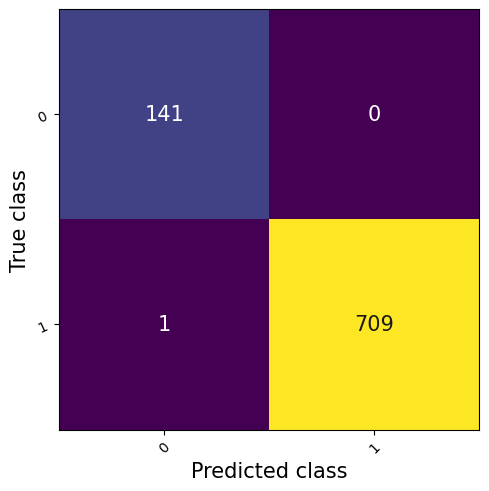

In [6]:

# Recoge predicciones y etiquetas reales
pred_labels = []
gt_labels   = []

for batch in predictions:
    for item in batch:
        pred_labels.append(item.pred_label.item())
        gt_labels.append(item.gt_label.item())

pred_labels = torch.tensor(pred_labels)
gt_labels   = torch.tensor(gt_labels)

# Calcula la confusion matrix
matrix = BinaryConfusionMatrix( )
matrix.update(pred_labels, gt_labels)
figure = matrix.plot()
plt.show()

In [ ]:

# Visualiza
tn, fp, fn, tp = matrix.flatten().tolist()

fig, ax = plt.subplots(figsize=(6, 5))
data = np.array([[tn, fp], [fn, tp]])

im = ax.imshow(data, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal", "Anomalía"])
ax.set_yticklabels(["Normal", "Anomalía"])
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, data[i, j], ha="center", va="center",
                color="white" if data[i, j] > data.max() / 2 else "black",
                fontsize=14, fontweight="bold")

labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.3, labels[i][j], ha="center", va="center",
                color="white" if data[i, j] > data.max() / 2 else "black",
                fontsize=10)

plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos     (FP): {fp}")
print(f"Falsos Negativos     (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")
print(f"\nPrecisión:  {tp / (tp + fp):.4f}")
print(f"Recall:     {tp / (tp + fn):.4f}")
print(f"F1Score:    {2*tp / (2*tp + fp + fn):.4f}")

In [ ]:
from torchmetrics.classification import (
    BinaryAUROC,
    BinaryF1Score,
    BinaryPrecision,
    BinaryRecall,
    BinaryConfusionMatrix,
)

# Recoge scores y labels
scores = torch.tensor([item.pred_score.item() for batch in predictions for item in batch])
labels = torch.tensor([item.gt_label.item()   for batch in predictions for item in batch])
preds  = torch.tensor([item.pred_label.item() for batch in predictions for item in batch])

# Calcula todas las métricas
auroc_val     = BinaryAUROC()(scores, labels).item()
f1_val        = BinaryF1Score()(preds, labels).item()
precision_val = BinaryPrecision()(preds, labels).item()
recall_val    = BinaryRecall()(preds, labels).item()

print(f"AUROC:     {auroc_val:.4f}")
print(f"F1Score:   {f1_val:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall:    {recall_val:.4f}")

